## 1D Fiting with SASView from notebook
## Peak Voigt hexagonal model template notebook

* import all the packages
* install packages before using a separate notebook
* better to work in a dedicated python environnement

In [1]:
import numpy as np

import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

* Configuration of matplotlib for plots

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

### Load a 1D data file

* load an experimental data file .dat
* define here filename and path on your computer

In [3]:
filenameraw = "./data-examples/PR32M_3mM8A2_00724{00000}_AzInt_Px_0.dat"

* subtraction from empty file

In [4]:
fileempty = "./data-examples/Ave_117_water0p05_00011AzInt_Px.dat"

total number of data points:  1208
total empty number of data points:  1208


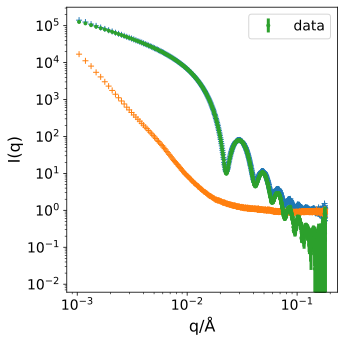

In [5]:
# number of lines in the header
skipheader = 47

# Using loadtxt to load data
data_np = np.loadtxt(filenameraw, skiprows=skipheader)

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# datasub incorporates the subtraction of empty file
coeffempty = 0.88
empty_np = np.loadtxt(fileempty, skiprows=skipheader-20)
total_empty_data_number = empty_np.shape[0]
print('total empty number of data points: ', total_empty_data_number)

plt.loglog(empty_np[:,0], empty_np[:,1], '+')

datasub = sasmodels.data.Data1D(
    x=data_np[0:total_data_number, 0],
    y=data_np[0:total_data_number, 1] - coeffempty*empty_np[0:total_data_number, 1],
    dy=data_np[0:total_data_number, 2])

sasmodels.data.plot_data(datasub)

In [6]:
subfilename = filenameraw[:-4] + '_sub.dat'

with open(subfilename, 'w') as f:
    f.write('raw data file is:' + filenameraw + '\n')
    f.write('number of data points: \t' + str(total_data_number) + '\n')

with open(subfilename, 'a') as fa:
    for i in range(0, total_data_number):
        line_to_write = str(datasub.x[i]) + '\t' + str(datasub.y[i]) + '\t' + str(datasub.dy[i]) + '\n'
        fa.write(line_to_write)

In [7]:
filename = subfilename

Process the data file:
* use `skipheader` to skip the header
* use `skipmin` to skip data points at low q values
  (**important**: `q = 0` makes `(scale_Porod/q)**4 = inf` — always skip it)
* use `skipmax` to skip data points at large q values
* use `slicing_step` to reduce the number of data points
* use `rescale` to convert intensity to cm⁻¹
* use `coeff` to build error bars as a percentage of intensity

total number of data points:  1208
after skip at low and large q values: 908
points removed by cleaning (q<=0 / NaN / I<=0): 0
final number of data points: 908
q > 0: True | y > 0: True | dy > 0: True | all finite: True


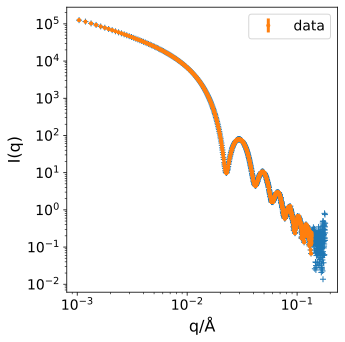

In [8]:
# number of lines in the header
skipheader = 2

# Using loadtxt to load data
data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# number of points to skip at low / high q (reference-style trimming)
skipmin = 0
skipmax = 300
number_of_data = total_data_number - skipmax - skipmin
print('after skip at low and large q values:', number_of_data)

# guard: fail loudly if skipmax/skipmin remove everything
if number_of_data <= 0:
    raise ValueError(f'skipmin+skipmax ({skipmin}+{skipmax}) >= data length '
                     f'({total_data_number}); reduce skipmax')

slicing_step = 1   # step of slicing

# rescaling of intensity values to cm-1
rescale = 1

# error bars: 10% of intensity values (mirrors reference notebook)
coeff = 0.1

xv = data_np[skipmin:skipmin + number_of_data:slicing_step, 0]
yv = rescale * data_np[skipmin:skipmin + number_of_data:slicing_step, 1]
ev = rescale * coeff * data_np[skipmin:skipmin + number_of_data:slicing_step, 1]

# === BULLETPROOF CLEANING ===
# (scale_Porod/q)**4 is infinite at q=0, and subtraction can leave NaN / negative I.
# Any of these makes chisq infinite, so drop them here once and for all.
mask = np.isfinite(xv) & (xv > 0) & np.isfinite(yv) & (yv > 0) & np.isfinite(ev) & (ev > 0)
xv, yv, ev = xv[mask], yv[mask], ev[mask]
print('points removed by cleaning (q<=0 / NaN / I<=0):', int(np.sum(~mask)))

data = sasmodels.data.Data1D(x=xv, y=yv, dy=ev)
datasub = sasmodels.data.Data1D(x=xv, y=yv, dy=ev)

number_of_data_new = data.x.shape[0]
print('final number of data points:', number_of_data_new)

# safety check — all four MUST be True before fitting
print('q > 0:', bool(np.all(data.x > 0)),
      '| y > 0:', bool(np.all(data.y > 0)),
      '| dy > 0:', bool(np.all(data.dy > 0)),
      '| all finite:', bool(np.all(np.isfinite(data.y)) and np.all(np.isfinite(data.dy))))

sasmodels.data.plot_data(data)

* plot of the new data set `data`

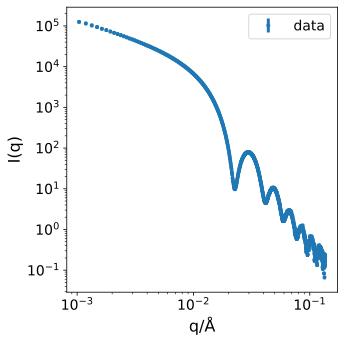

In [9]:
sasmodels.data.plot_data(data)

### save `data` in a new data file
* add `_new` at the end of the name

In [10]:
newfilename = filename[:-4] + '_new.dat'

with open(newfilename, 'w') as f:
    f.write('raw data file is:' + filename + '\n')
    f.write('number of data points: \t' + str(number_of_data_new) + '\n')

with open(newfilename, 'a') as fa:
    for i in range(0, number_of_data_new):
        line_to_write = str(data.x[i]) + '\t' + str(data.y[i]) + '\t' + str(data.dy[i]) + '\n'
        fa.write(line_to_write)

In [11]:
qstart = data.x[0]
print(qstart)

0.0010392659473367853


In [12]:
qend = data.x[number_of_data_new-1]
print(qend)

0.1356731133420249


In [13]:
Istart = data.y[0]
print(Istart)

126110.49972498295


In [14]:
Iend = data.y[number_of_data_new-1]
print(Iend)

0.21603344650580647


### fit the data

* create the computation `kernel` selecting the `cylinder+porod_peak_voigt_hexagonal` model
* create the `model` interfaced with bumps module
* create the `experiment`, containing both data and model

In [15]:
kernel = sasmodels.core.load_model("cylinder+porod_peak_voigt_hexagonal")
params = {}  # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

* default values of all parameters

In [16]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'A_scale': 1.0,
 'A_sld': 4,
 'A_sld_solvent': 1,
 'A_radius': 20,
 'A_length': 400,
 'A_theta': 60,
 'A_phi': 60,
 'B_scale': 1.0,
 'B_scale_Porod': 0.05,
 'B_a_cell': 900,
 'B_w_f': 0.8,
 'B_hwhm_q10': 0.01,
 'B_hwhm_q11': 0.01,
 'B_hwhm_q20': 0.01,
 'B_hwhm_q21': 0.01,
 'B_hwhm_q30': 0.01,
 'B_scale_q10': 1,
 'B_scale_q11': 1,
 'B_scale_q20': 1,
 'B_scale_q21': 0,
 'B_scale_q30': 0,
 'up_frac_i': 0.0,
 'up_frac_f': 0.0,
 'up_theta': 90.0,
 'up_phi': 0.0,
 'A_sld_M0': 0.0,
 'A_sld_mtheta': 0.0,
 'A_sld_mphi': 0.0,
 'A_sld_solvent_M0': 0.0,
 'A_sld_solvent_mtheta': 0.0,
 'A_sld_solvent_mphi': 0.0}

#### preliminary step: manual adjustment of parameters before fitting
Don't forget updating the SLD values (x10-6 A-2) !
* silver: 77.9
* water: 9.4

In [17]:
sld_silver = 77.9
sld_water = 9.4

Model name = cylinder+porod_peak_voigt_hexagonal

In [18]:
model_name = "cylinder+porod_peak_voigt_hexagonal"

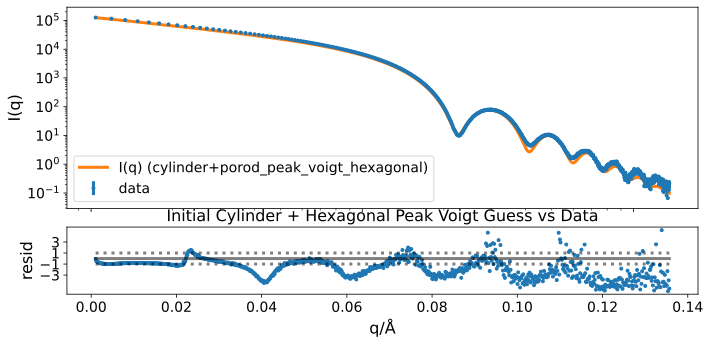

In [19]:

hwhm= 2e-4
params = {
    # --- GLOBAL ---
    "scale": 1e-3, 
    "background": 0.0, # Lock to 0 to prevent background crash
    
    # --- COMPONENT A (Cylinder) ---
    "A_scale": 1,   # Scaled down to match standard SAS intensity
    "A_sld": sld_silver,
    "A_sld_solvent": sld_water,
    "A_radius": 170,
    "A_length": 2e+4,
    "A_radius_pd_type": 'gaussian', #type of polydispersity function
    "A_radius_pd": 0.05, #polydispersity
    "A_radius_pd_n": 8, #number of steps in polydispersity
    "A_radius_pd_nsigma": 4, #number of steps in polydispersity
    #"A_theta": 60.0,  
    #"A_phi": 60.0,    
    
    # --- COMPONENT B (Porod + Hexagonal Peak Voigt) ---
    "B_scale": 0,   # Scaled down
    "B_scale_Porod":2e-3,
    "B_a_cell": 920.0,    # Set to 800 based on your sample's expected spacing
    "B_w_f": 0.8,
    
    "B_hwhm_q10": hwhm,
    "B_hwhm_q11": hwhm,
    "B_hwhm_q20": hwhm,
    "B_hwhm_q21": hwhm,
    "B_hwhm_q30": hwhm,
    
    # Brought peak guesses down to reality so Chi2 doesn't explode!
    "B_scale_q10": 1,
    "B_scale_q11": 0.5,
    "B_scale_q20": 0.01,
    "B_scale_q21": 0.01,
    "B_scale_q30": 0.01,
}

# Build the model and experiment
model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

# Plot the initial guess against your data
plt.figure(figsize=(10, 5))
experiment.plot()
plt.title("Initial Cylinder + Hexagonal Peak Voigt Guess vs Data")
plt.show()

## fitting the data

* choice of the initial values for parameters
* choice of the fitting parameters with their fitting range

**Parameter guide:**
* `A_scale` controls the cylinder amplitude — increase to raise the cylinder contribution
* `B_scale` controls the overall Bragg peak + Porod amplitude — increase to raise peaks
* `B_a_cell` sets all peak positions: q₁₀ = 4π/(√3·a), q₁₁ = √3·q₁₀, etc.
* `B_hwhm_q*` sets individual peak widths — must be > 0
* `B_scale_q*` sets individual peak amplitudes — set to 0 to suppress a peak
* Comment out any `.range()` line to keep that parameter fixed during the fit

step 1 cost 6.0318(39)
                                A_radius ...|......        170 in [150, 200]
                             A_radius_pd ....|.....       0.05 in [0.01, 0.1]
                                   scale |.........      0.001 in [0.0001, 0.01]
step 2 cost 4.0029(39)
step 3 cost 3.9887(39)
step 4 cost 3.9883(39)
step 5 cost 3.9883(39)
step 6 cost 3.9883(39)
                                A_radius ....|.....    170.868 in [150, 200]
                             A_radius_pd ....|.....  0.0491161 in [0.01, 0.1]
                                   scale .|........ 0.00117427 in [0.0001, 0.01]
step 7 cost 3.9883(39)
step 7 cost 3.9883(39) [final]
                                A_radius ....|.....    170.868 in [150, 200]
                             A_radius_pd ....|.....   0.049115 in [0.01, 0.1]
                                   scale .|........ 0.00117428 in [0.0001, 0.01]
time 40.7 seconds
Fit results for problem: χ² = 3.9883(39)
=== Uncertainty from curvature:     name 

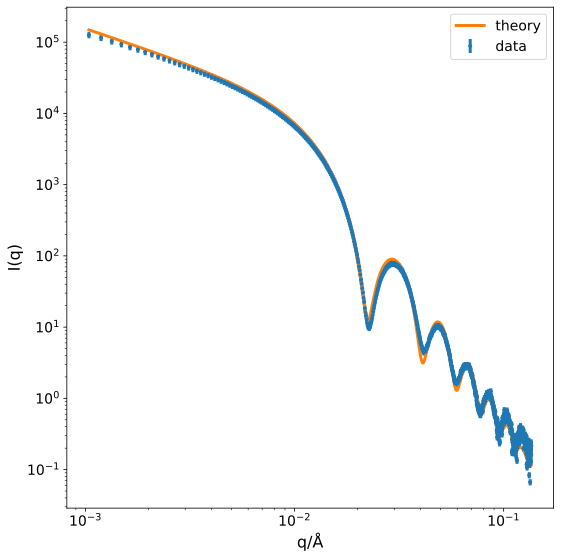

In [20]:
model = sasmodels.bumps_model.Model(model=kernel, **params)

model.scale.range(1e-4,1e-2) 
# 1. Component A Ranges (Cylinder)
#model.A_scale.range(1e-4,1e-2)
model.A_radius.range(150,200) 
model.A_radius_pd.range(0.01,0.1)        
#model.A_length.range:(800)

# 2. Component B Ranges (Hexagonal Peaks)
#model.B_scale.range(1e+2, 1e+6)
#model.B_scale_Porod.range(0.001 , 0.03)
#model.B_a_cell.range(850,950) # Give it plenty of room to find the ~800 A spacing safely

# Allow primary and secondary peak heights and widths to adjust
#model.B_scale_q10.range(0.1, 2)
#model.B_hwhm_q10.range(0.0001, 0.01)

#model.B_scale_q11.range(0.1, 2)
#model.B_hwhm_q11.range(0.0001, 0.01)

#model.B_scale_q20.range(0.0,0.4)
#model.B_hwhm_q20.range(0.0001, 0.01)

#model.B_scale_q21.range(0.0,0.4)
#model.B_hwhm_q21.range(0.0001, 0.01)

#model.B_scale_q30.range(0.0,0.4)
#model.B_hwhm_q30.range(0.0001, 0.01)

experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=10, 
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
#problem.plot()
print(problem.summarize())
print(model.state())
print(problem.summarize())
print(problem.chisq())
sasmodels.data.plot_theory(data,experiment.Iq_calc)

In [25]:
print(model.state())
print(problem.summarize())
print(problem.chisq())

{'scale': 0.0011742782927976982, 'background': 0.0, 'A_scale': 1.0, 'A_sld': 77.9, 'A_sld_solvent': 9.4, 'A_radius': 170.86827432568123, 'A_radius_pd': 0.0491149862288403, 'A_radius_pd_n': 8.0, 'A_radius_pd_nsigma': 4.0, 'A_length': 20000.0, 'A_length_pd': 0.0, 'A_length_pd_n': 35.0, 'A_length_pd_nsigma': 3.0, 'A_theta': 60.0, 'A_theta_pd': 0.0, 'A_theta_pd_n': 35.0, 'A_theta_pd_nsigma': 3.0, 'A_phi': 60.0, 'A_phi_pd': 0.0, 'A_phi_pd_n': 35.0, 'A_phi_pd_nsigma': 3.0, 'B_scale': 0.0, 'B_scale_Porod': 0.002, 'B_a_cell': 920.0, 'B_w_f': 0.8, 'B_hwhm_q10': 0.0002, 'B_hwhm_q11': 0.0002, 'B_hwhm_q20': 0.0002, 'B_hwhm_q21': 0.0002, 'B_hwhm_q30': 0.0002, 'B_scale_q10': 1.0, 'B_scale_q11': 0.5, 'B_scale_q20': 0.01, 'B_scale_q21': 0.01, 'B_scale_q30': 0.01, 'up_frac_i': 0.0, 'up_frac_f': 0.0, 'up_theta': 90.0, 'up_phi': 0.0, 'A_sld_M0': 0.0, 'A_sld_mtheta': 0.0, 'A_sld_mphi': 0.0, 'A_sld_solvent_M0': 0.0, 'A_sld_solvent_mtheta': 0.0, 'A_sld_solvent_mphi': 0.0, 'A_radius_pd_type': 'gaussian', 'A_

* store the fitted values in handy variables

In [26]:
R_fit = model.A_radius.value
L_fit = model.A_length.value
a_cell_fit = model.B_a_cell.value

print('A_radius =', R_fit)
print('A_length =', L_fit)
#print('B_a_cell =', a_cell_fit)

A_radius = 170.86827432568123
A_length = 20000.0


#### Save the fitted curve in a file
* `_fit` is added at the end of filename

In [27]:
fitfilename = filename[:-4] + '_fit.dat'

with open(fitfilename, 'w') as f:
    f.write('raw data file is:' + filename + '\n')
    f.write('number of data points: \t' + str(number_of_data_new) + '\n')

with open(fitfilename, 'a') as fa:
    for i in range(0, number_of_data_new-1):
        line_to_write = str(data.x[i]) + '\t' + str(experiment.Iq_calc[i]) + '\n'
        fa.write(line_to_write)

### final plot
* use this one for a nice .svg output

3.98830342227154


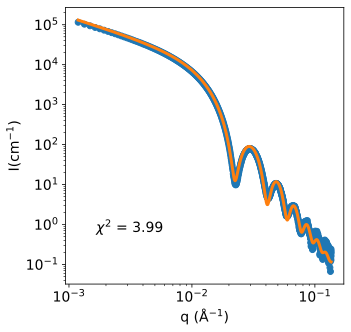

In [28]:
data_final = np.loadtxt(newfilename, skiprows=3)

fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)', fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)', fontsize=14)
plt.text(qstart*3, Iend*3, r'$\chi^2$ = '+f"{problem.chisq():.2f}",
         fontsize=14, horizontalalignment='center')
print(problem.chisq())